# Modeling - Degroot and Friekin Johnsen

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'

INIT_ROOT = Path('../..').joinpath('..').resolve()
PAIR_DIR = INIT_ROOT / 'tests' / 'single_shot_tests' / 'data' / 'stance_converted'

PARAMS = {
    'stance_clip': (-1.0, 1.0),
    'lambda_grid': np.linspace(0.05, 0.95, 19),
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

PREDICTOR_PARAMS = {
    'basis_grid': ['linear', 'linear_abs', 'quadratic', 'quadratic_abs'],
    'ridge_alphas': [0.0, 0.1, 1.0, 10.0],
    'noise_bins': 6,
    'rng_seed': 0,
}

USE_PREDICTED_INIT_WHEN_NO_SLICE0_SELF_POST = True

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
print('Rollout horizon cap:', PARAMS['rollout_horizon_cap'])
print('Pair dir:', PAIR_DIR)
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Cleaned data: /Users/samuelli/Documents/code/llm/llm-network/modeling/cleaned_data
Runs found: 47
Rollout horizon cap: 20
Pair dir: /Users/samuelli/Documents/code/llm/tests/single_shot_tests/data/stance_converted
  run_20260320-130058
  run_20260320-133304
  run_20260320-140500
  run_20260320-143643
  run_20260320-150827
  run_20260320-154019
  run_20260320-161210
  run_20260320-164400
  run_20260320-171544
  run_20260320-174722
  run_20260321-121900
  run_20260321-125108
  run_20260321-132251
  run_20260321-135440
  run_20260321-142622
  run_20260321-145803
  run_20260321-152938
  run_20260321-160106
  run_20260321-163235
  run_20260321-170416
  run_20260322-212540
  run_20260324-095805
  run_20260324-115915
  run_20260324-135956
  run_20260324-160041
  run_20260326-014533


## Data Construction

- Per-run, per-agent stance trajectory is represented as $x_i^{(r)}(t)$.
- Initialization uses run-derived signals and global fallback priors from observed runs.
- Each run is mapped onto a shared global agent index.
- Neighbor sets are built per run from that run's graph: $\mathcal{N}^{(r)}_i$.

In [2]:
from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
# print (GLOBAL_INIT_BY_AGENT)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(d, GLOBAL_AGENT_IDS, target_agent_fraction=0.4, return_post_mask=True, constrain_messages=150)
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f"{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}")

Global agent count: 30
Global init priors available: 30
run_20260320-130058: trajectory shape=(9, 30), horizon=8
run_20260320-133304: trajectory shape=(12, 30), horizon=11
run_20260320-140500: trajectory shape=(10, 30), horizon=9
run_20260320-143643: trajectory shape=(9, 30), horizon=8
run_20260320-150827: trajectory shape=(10, 30), horizon=9
run_20260320-154019: trajectory shape=(11, 30), horizon=10
run_20260320-161210: trajectory shape=(9, 30), horizon=8
run_20260320-164400: trajectory shape=(11, 30), horizon=10
run_20260320-171544: trajectory shape=(10, 30), horizon=9
run_20260320-174722: trajectory shape=(10, 30), horizon=9
run_20260321-121900: trajectory shape=(11, 30), horizon=10
run_20260321-125108: trajectory shape=(11, 30), horizon=10
run_20260321-132251: trajectory shape=(8, 30), horizon=7
run_20260321-135440: trajectory shape=(12, 30), horizon=11
run_20260321-142622: trajectory shape=(11, 30), horizon=10
run_20260321-145803: trajectory shape=(10, 30), horizon=9
run_20260321-

In [3]:
# RUN_TRAJ posting audit: use post mask to separate true posts from feed-forward values.
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")


RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260320-130058: post_mean=0.252, post_min=0.133, post_max=0.367, slices=9
run_20260320-133304: post_mean=0.242, post_min=0.167, post_max=0.333, slices=12
run_20260320-140500: post_mean=0.310, post_min=0.067, post_max=0.433, slices=10
run_20260320-143643: post_mean=0.267, post_min=0.200, post_max=0.367, slices=9
run_20260320-150827: post_mean=0.257, post_min=0.033, post_max=0.367, slices=10
run_20260320-154019: post_mean=0.261, post_min=0.133, post_max=0.400, slices=11
run_20260320-161210: post_mean=0.274, post_min=0.167, post_max=0.433, slices=9
run_20260320-164400: post_mean=0.261, post_min=0.067, post_max=0.400, slices=11
run_20260320-171544: post_mean=0.287, post_min=0.067, post_max=0.400, slices=10
run_20260320-174722: post_mean=0.263, post_min=0.200, post_max=0.433, slices=10
run_20260321-121900: post_mean=0.245, post_min=0.133, post_max=0.333, slices=11
run_20260321-125108: post_mean=0.270, post_m

In [4]:
def build_dataset_from_run(run):
    X = []
    Y = []
    for t in range(len(run) - 1):
        X.append(run[t])
        Y.append(run[t + 1])
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    return X, Y

## DeGroot - Predict

In [5]:
import cvxpy as cp

def fit_row_stochastic_W_from_pooled_runs(run_traj_map, run_neighbors):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for run_name in run_names[1:]:
        if run_neighbors[run_name] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    X_blocks = []
    Y_blocks = []
    for run_name in run_names:
        X, Y = build_dataset_from_run(np.asarray(run_traj_map[run_name], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)

    n = X_pool.shape[1]
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        ns = ref_neighbors[i]
        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]

        w_ns = cp.Variable(len(ns))
        objective = cp.Minimize(cp.sum_squares(X_ns @ w_ns - y))
        constraints = [w_ns >= 0, cp.sum(w_ns) == 1]
        problem = cp.Problem(objective, constraints)
        problem.solve()

        row = np.zeros(n, dtype=float)
        row[ns] = np.asarray(w_ns.value, dtype=float).ravel()
        W[i] = row

    return W, X_pool, Y_pool

In [6]:
GLOBAL_W, X_pool, Y_pool = fit_row_stochastic_W_from_pooled_runs(RUN_TRAJ, RUN_NEIGHBORS)

print('Min entry:', float(GLOBAL_W.min()), 'Max entry:', float(GLOBAL_W.max()))
print("Global MSE loss:", float(np.mean((Y_pool - X_pool @ GLOBAL_W.T) ** 2)))
print('DeGroot W eigenvalues:', np.linalg.eigvals(GLOBAL_W))
print('DeGroot W spectral radius:', float(np.max(np.abs(np.linalg.eigvals(GLOBAL_W)))))

Min entry: -5.063838321866517e-17 Max entry: 0.715293248320988
Global MSE loss: 0.026252235246082733
DeGroot W eigenvalues: [ 1.        +0.j          0.78656153+0.j          0.77642239+0.j
  0.63298546+0.j          0.50218394+0.j         -0.68745723+0.j
 -0.64601088+0.j          0.42130843+0.j          0.28686216+0.j
 -0.43770988+0.08929791j -0.43770988-0.08929791j  0.10540907+0.16550662j
  0.10540907-0.16550662j  0.1567218 +0.06924241j  0.1567218 -0.06924241j
 -0.37825003+0.j         -0.30624784+0.08906369j -0.30624784-0.08906369j
 -0.30768646+0.j         -0.23154826+0.11638129j -0.23154826-0.11638129j
 -0.23389534+0.05450211j -0.23389534-0.05450211j  0.03644484+0.j
 -0.04588189+0.07920736j -0.04588189-0.07920736j -0.2036656 +0.j
 -0.14235328+0.j         -0.0366816 +0.j         -0.05435901+0.j        ]
DeGroot W spectral radius: 1.0000000000000018


In [7]:
print (GLOBAL_W[0])

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -1.19909981e-17 -3.00970179e-17  1.36432158e-01  0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.25889796e-01 -2.23892536e-17
  0.00000000e+00  4.28764893e-01 -8.99620510e-18  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  2.08913153e-01  0.00000000e+00]


In [8]:
def degroot_rollout_prediction(W, x0, horizon):
    predictions = [x0]
    current_x = x0.copy()
    for t in range(horizon):
        current_x = W @ current_x
        predictions.append(current_x.copy())
    return predictions
    
PREDICTED_TRAJ = {rn: degroot_rollout_prediction(GLOBAL_W, tr[0], PARAMS['rollout_horizon_cap']) for rn, tr in RUN_TRAJ.items()}

run_20260326-034648


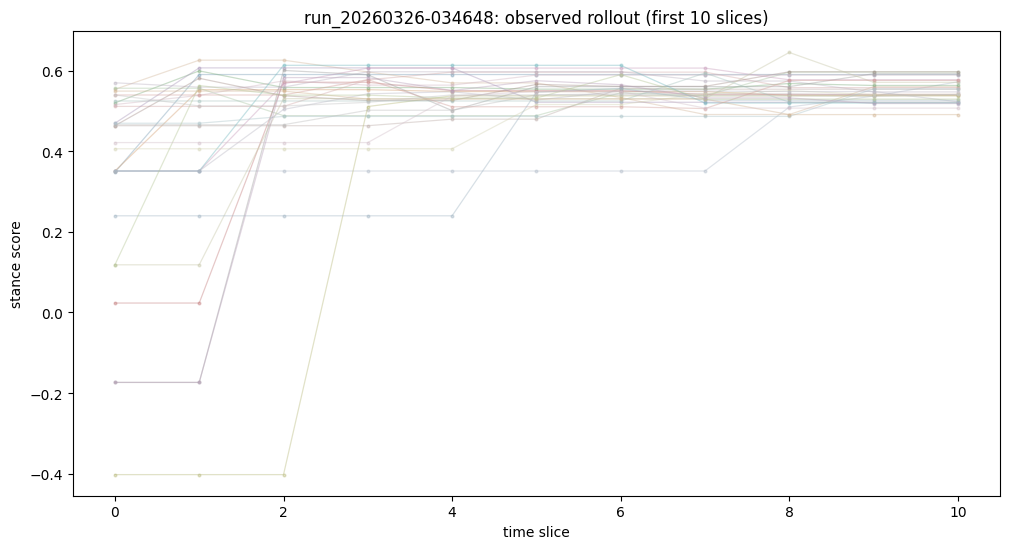

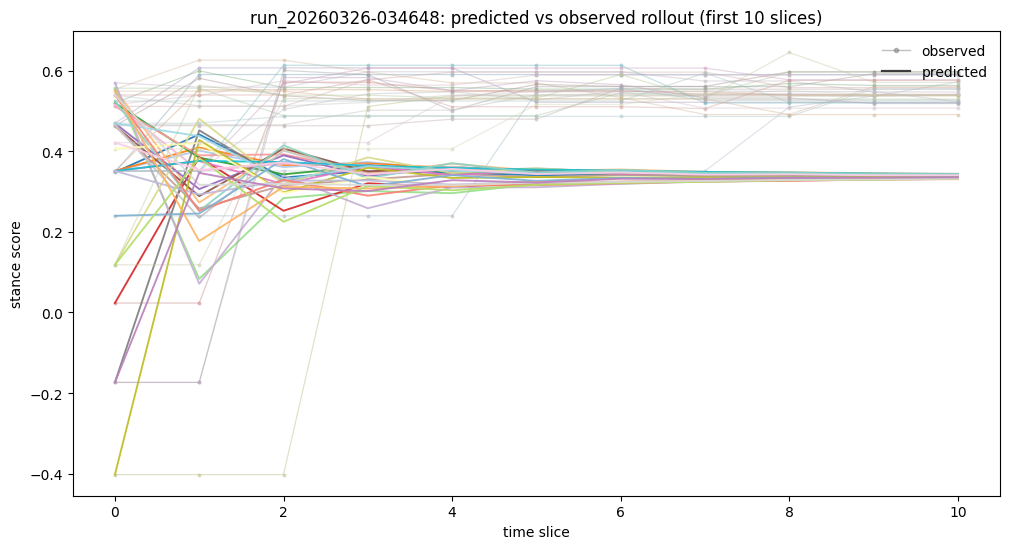

Steady-state mean (observed): 0.5494246046162314
Steady-state mean (predicted): 0.33853437440074075
Steady-state variance (observed): 0.0009288583287569726
Steady-state variance (predicted): 3.5174785902384226e-05
Wasserstein distance: 0.1787


In [9]:
# Mean, Variance, Wasserstein helpers
from plot_utils import plot_observed_trajectories, plot_predicted_vs_observed, calculate_mean_and_variance, compute_wasserstein_distance
run_names = sorted(RUN_TRAJ.keys())

print (run_names[26])

plot_observed_trajectories(run_names[26], RUN_TRAJ[run_names[26]], GLOBAL_AGENT_IDS, 20)
plot_predicted_vs_observed(run_names[26], RUN_TRAJ[run_names[26]], PREDICTED_TRAJ[run_names[26]], GLOBAL_AGENT_IDS, 20)

T = min(np.asarray(RUN_TRAJ[run_names[26]]).shape[0], np.asarray(PREDICTED_TRAJ[run_names[26]]).shape[0])
obs = RUN_TRAJ[run_names[26]][:T]
pred = PREDICTED_TRAJ[run_names[26]][:T]

mean_var_metrics = calculate_mean_and_variance(obs, pred, last_n=3)
print(f"Steady-state mean (observed): {mean_var_metrics['steady_mean_obs']}")
print(f"Steady-state mean (predicted): {mean_var_metrics['steady_mean_pred']}")
print(f"Steady-state variance (observed): {mean_var_metrics['steady_var_obs']}")
print(f"Steady-state variance (predicted): {mean_var_metrics['steady_var_pred']}")

W_metric = compute_wasserstein_distance(obs, pred)
print(f"Wasserstein distance: {W_metric:.4f}")

In [10]:
print (X_pool)

[[0.58594107 0.54584526 0.42816955 ... 0.57051744 0.49968562 0.43171439]
 [0.58594107 0.54584526 0.42816955 ... 0.54976541 0.49968562 0.43171439]
 [0.59753174 0.54584526 0.42816955 ... 0.54976541 0.49968562 0.43171439]
 ...
 [0.58715843 0.56715305 0.56842022 ... 0.55795362 0.37672504 0.53042835]
 [0.58715843 0.56435378 0.56842022 ... 0.55795362 0.50220574 0.53042835]
 [0.53915738 0.56435378 0.56842022 ... 0.55890466 0.54731824 0.55935527]]


In [21]:
from plot_utils import compute_eigenvalue
result = compute_eigenvalue(X_pool, Y_pool, RUN_NEIGHBORS[run_names[0]], intercepts=False)
print('full eigenvalues:', len(result['eigvals_full']))
print('reduced eigenvalues:', len(result['eigvals_reduced']))
print('active params:', result['active_param_count'])
print (result['eigvals_full'])

[[0.58594107 0.54584526 0.42816955 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.55890466 0.54731824 0.55935527]]
full eigenvalues: 900
reduced eigenvalues: 210
active params: 210
[1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 1.40308740e+00 1.40308740e+00
 1.40308740e+00 1.40308740e+00 2.01368781e+00 2.01368781e+00
 2

## Friedkin Johnsen Model - Static Graph structure based

In [12]:
def build_x0_from_agent_inits(agent_inits, n):
    x0 = np.full((n,), np.nan, dtype=float)
    for aid, val in agent_inits.items():
        idx = int(aid.split('_', 1)[1]) - 1
        x0[idx] = float(val)
    if np.isnan(x0).any():
        missing = np.where(np.isnan(x0))[0].tolist()
        raise ValueError(f'missing init values for indices: {missing}')
    return x0

In [13]:
#friedkin johnsen setup

def fit_friedkin_johnsen(run_traj_map, run_neighbors, lambda1, lambda2, agent_inits):
    if lambda1 < 0 or lambda2 < 0 or lambda1 + lambda2 > 1:
        raise ValueError('lambda1 and lambda2 must be nonnegative and satisfy lambda1 + lambda2 <= 1')

    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    # Ensure same graph across runs
    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs')
        

    # Build pooled dataset
    X_blocks, Y_blocks, X0_blocks = [], [], []
    for rn in run_names:
        traj = np.asarray(run_traj_map[rn], dtype=float)
        X, Y = build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    n = X_pool.shape[1]
    alpha = 1.0 - lambda1 - lambda2

    b = cp.Variable()  # scalar global bias
    W_vars = []        # store per-row variables
    objective_terms = []
    constraints = []

    x0_init = build_x0_from_agent_inits(agent_inits, n)

    for i in range(n):
        ns = ref_neighbors[i]
        if len(ns) == 0:
            continue  # skip isolated nodes safely

        w_ns = cp.Variable(len(ns))
        W_vars.append((i, ns, w_ns))

        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]
        x0i = float(x0_init[i])

        pred = lambda1 * x0i + lambda2 * b + alpha * (X_ns @ w_ns)
        objective_terms.append(cp.sum_squares(y - pred))

        constraints += [
            w_ns >= 0,
            cp.sum(w_ns) == 1,
        ]

    # bias constraint
    constraints += [b >= -1, b <= 1]

    objective = cp.Minimize(cp.sum(objective_terms))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if b.value is None:
        raise RuntimeError('Solver failed')

    # ---- RECONSTRUCT W ----
    W = np.zeros((n, n), dtype=float)
    for (i, ns, w_ns) in W_vars:
        W[i, ns] = np.asarray(w_ns.value).ravel()

    return W, float(b.value), X_pool, Y_pool

In [14]:
def friedkin_johnsen_rollout_prediction(W, bias, x0, horizon, lambda1, lambda2):
    alpha = 1.0 - lambda1 - lambda2
    x0 = np.asarray(x0, dtype=float)
    current_x = x0.copy()
    predictions = [current_x.copy()]
    bias_vec = np.full_like(current_x, float(bias), dtype=float)

    for _ in range(horizon):
        current_x = lambda1 * x0 + lambda2 * bias_vec + alpha * (W @ current_x)
        predictions.append(current_x.copy())

    return predictions


def select_friedkin_johnsen_lambdas(run_traj_map, run_neighbors, lambda_grid, agent_inits):
    run_names = sorted(run_traj_map.keys())
    best_result = None
    all_results = []

    for lambda1 in lambda_grid:
        for lambda2 in lambda_grid:
            if lambda1 + lambda2 > 1:
                continue

            W_hat, b_hat, _, _ = fit_friedkin_johnsen(run_traj_map, run_neighbors, lambda1, lambda2, agent_inits)
            predicted_traj = {
                rn: friedkin_johnsen_rollout_prediction(
                    W_hat,
                    b_hat,
                    tr[0],
                    PARAMS['rollout_horizon_cap'],
                    lambda1,
                    lambda2,
                )
                for rn, tr in run_traj_map.items()
            }

            wasserstein_scores = []
            for rn in run_names:
                obs = np.asarray(run_traj_map[rn], dtype=float)
                pred = np.asarray(predicted_traj[rn], dtype=float)
                T = min(obs.shape[0], pred.shape[0])
                obs = obs[:T]
                pred = pred[:T]
                wasserstein_scores.append(compute_wasserstein_distance(obs, pred))

            mean_wasserstein = float(np.mean(wasserstein_scores))
            result = {
                'lambda1': float(lambda1),
                'lambda2': float(lambda2),
                'mean_wasserstein': mean_wasserstein,
            }
            all_results.append(result)

            if best_result is None or mean_wasserstein < best_result['mean_wasserstein']:
                best_result = result

    return best_result, all_results

In [15]:
from plot_utils import plot_observed_trajectories, plot_predicted_vs_observed, calculate_mean_and_variance, compute_wasserstein_distance

best_fj_result, fj_lambda_search_results = select_friedkin_johnsen_lambdas(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    PARAMS['lambda_grid'],
    agent_inits=GLOBAL_INIT_BY_AGENT
)

FJ_LAMBDA1 = best_fj_result['lambda1']
FJ_LAMBDA2 = best_fj_result['lambda2']

print('Best Friedkin-Johnsen lambdas')
print('lambda1:', FJ_LAMBDA1)
print('lambda2:', FJ_LAMBDA2)
print('Best mean Wasserstein:', best_fj_result['mean_wasserstein'])

Best Friedkin-Johnsen lambdas
lambda1: 0.44999999999999996
lambda2: 0.5499999999999999
Best mean Wasserstein: 0.05699455218065821


Friedkin-Johnsen fit
Bias term: 0.5230625741389592
Global MSE loss: 0.02842068280582431


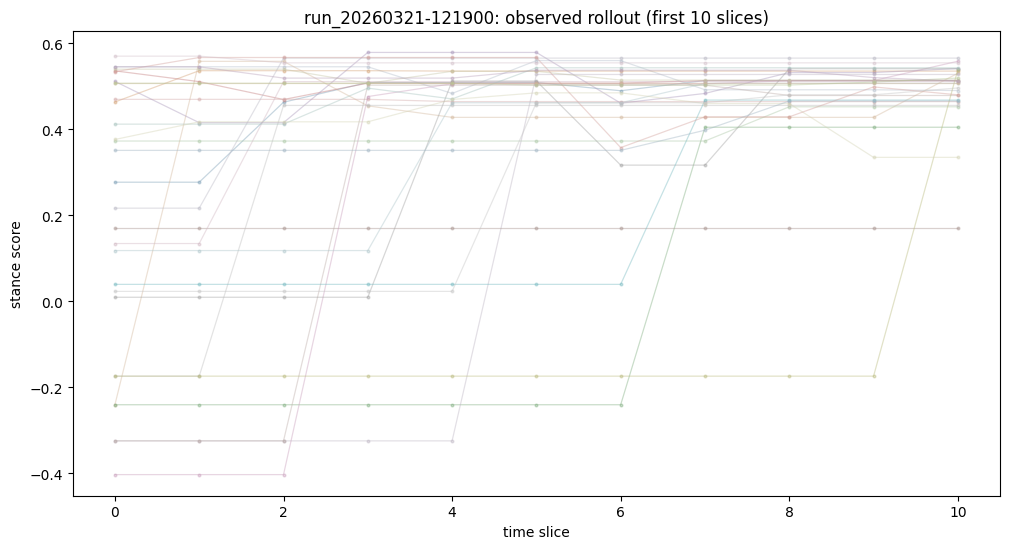

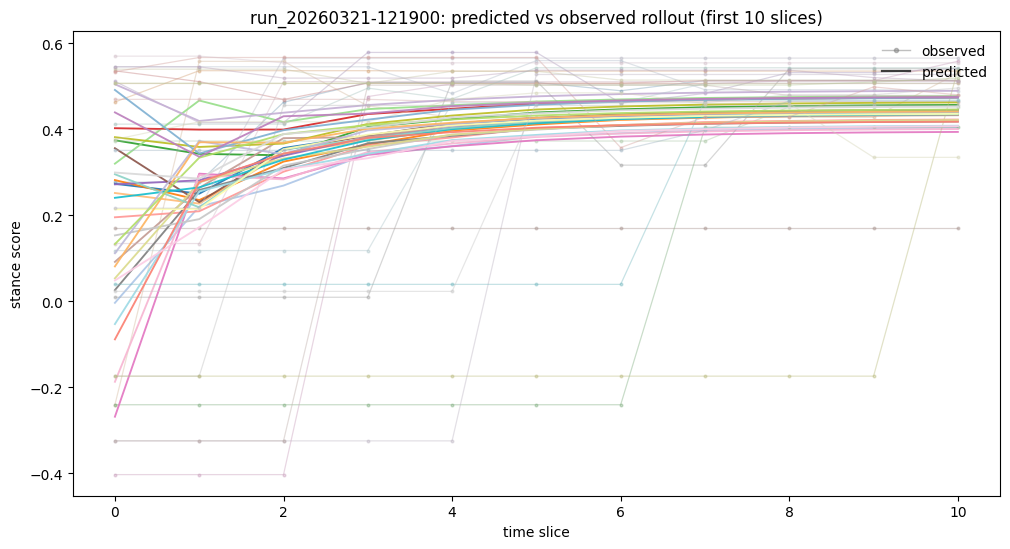

Average steady-state mean (observed): 0.45628570150826153
Average steady-state mean (predicted): 0.4332896773157634
Average steady-state variance (observed): 0.013277781374911962
Average steady-state variance (predicted): 0.000620488109984518
Average Wasserstein distance: 0.1007


In [16]:
FJ_LAMBDA1 = 0.1
FJ_LAMBDA2 = 0.3
FJ_W, FJ_b, X_pool_fj, Y_pool_fj = fit_friedkin_johnsen(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    FJ_LAMBDA1,
    FJ_LAMBDA2,
    GLOBAL_INIT_BY_AGENT
)

print('Friedkin-Johnsen fit')
print('Bias term:', FJ_b)
# print(FJ_W)
print('Global MSE loss:', float(np.mean((Y_pool_fj - X_pool_fj @ FJ_W.T) ** 2)))

PREDICTED_TRAJ_FJ = {
    rn: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_b,
        build_x0_from_agent_inits(GLOBAL_INIT_BY_AGENT, N),
        PARAMS['rollout_horizon_cap'],
        FJ_LAMBDA1,
        FJ_LAMBDA2,
    )
    for rn, tr in RUN_TRAJ.items()
}

run_names = sorted(RUN_TRAJ.keys())
run_id = run_names[10]

plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ[run_id], GLOBAL_AGENT_IDS, 10)

per_run_metrics = []
per_run_wass = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]

    per_run_metrics.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics]))
avg_mean_pred = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics]))
avg_var_obs = float(np.mean([m['steady_var_obs'] for m in per_run_metrics]))
avg_var_pred = float(np.mean([m['steady_var_pred'] for m in per_run_metrics]))
avg_wasserstein = float(np.mean(per_run_wass))

print(f"Average steady-state mean (observed): {avg_mean_obs}")
print(f"Average steady-state mean (predicted): {avg_mean_pred}")
print(f"Average steady-state variance (observed): {avg_var_obs}")
print(f"Average steady-state variance (predicted): {avg_var_pred}")
print(f"Average Wasserstein distance: {avg_wasserstein:.4f}")

## Friedkin Johnsen Joint Optimization

In [17]:
# Joint FJ fit with reparameterization: W_tilde = alpha * W, b_tilde = lambda2 * b

def fit_friedkin_johnsen_joint(run_traj_map, run_neighbors, agent_inits, eps=1e-4):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    # Build pooled transitions with per-transition run-level initial condition x0.
    X_blocks = []
    Y_blocks = []

    for rn in run_names:
        traj = np.asarray(run_traj_map[rn], dtype=float)
        X, Y = build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    _, n = X_pool.shape
    x0_init = build_x0_from_agent_inits(agent_inits, n)
    X0_pool = np.repeat(x0_init.reshape(1, -1), X_pool.shape[0], axis=0)
    # Decision variables.
    lambda1 = cp.Variable(nonneg=True)
    lambda2 = cp.Variable(nonneg=True)
    b_tilde = cp.Variable()  # equals lambda2 * b
    alpha = 1.0 - lambda1 - lambda2
    W_tilde = cp.Variable((n, n))

    # Least-squares objective on pooled transitions.
    ones_n = np.ones((n,), dtype=float)
    residual = Y_pool - (lambda1 * X0_pool + b_tilde * ones_n[None, :] + X_pool @ W_tilde.T)
    objective = cp.Minimize(cp.sum_squares(residual))
    constraints = []

    # Strict-like constraints via epsilon to support identifiability/bijection:
    # lambda1 + lambda2 < 1  ->  lambda1 + lambda2 <= 1 - eps
    # lambda2 != 0           ->  lambda2 >= eps
    constraints += [
        lambda2 >= eps,
        lambda1 >= 0.2,
        lambda1 + lambda2 <= 1.0 - eps,
        lambda1 <= 1.0,
    ]

    # Graph-structured nonnegative row constraints on W_tilde.
    for i in range(n):
        ns = ref_neighbors[i]
        allowed = np.zeros((n,), dtype=float)
        allowed[np.asarray(ns, dtype=int)] = 1.0

        constraints.append(W_tilde[i, :] >= 0)
        constraints.append(cp.sum(W_tilde[i, :]) == alpha)
        constraints.append(cp.multiply(1.0 - allowed, W_tilde[i, :]) == 0)

    # Since b in [-1, 1], b_tilde = lambda2 * b implies b_tilde in [-lambda2, lambda2].
    constraints += [
        b_tilde <= lambda2,
        b_tilde >= -lambda2,

    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if lambda1.value is None or lambda2.value is None or W_tilde.value is None or b_tilde.value is None:

        raise RuntimeError('Joint FJ optimization failed to produce a solution.')

    lambda1_hat = float(lambda1.value)
    lambda2_hat = float(lambda2.value)
    alpha_hat = 1.0 - lambda1_hat - lambda2_hat
    b_tilde_hat = float(b_tilde.value)
    W_tilde_hat = np.asarray(W_tilde.value, dtype=float)

    if alpha_hat <= eps:

        raise RuntimeError(f'Estimated alpha too small for stable W recovery: alpha={alpha_hat}')

    W_hat = W_tilde_hat / alpha_hat
    b_hat = b_tilde_hat / lambda2_hat

    # Build fitted pooled prediction and MSE in the same parameterization used for training.
    fitted_pool = lambda1_hat * X0_pool + b_tilde_hat * ones_n[None, :] + X_pool @ W_tilde_hat.T
    mse_pool = float(np.mean((Y_pool - fitted_pool) ** 2))

    return {
        'lambda1': lambda1_hat,
        'lambda2': lambda2_hat,
        'alpha': alpha_hat,
        'b_tilde': b_tilde_hat,
        'W_tilde': W_tilde_hat,
        'W': W_hat,
        'b': float(b_hat),
        'X_pool': X_pool,
        'Y_pool': Y_pool,
        'X0_pool': X0_pool,
        'mse_pool': mse_pool,
        'status': prob.status,
        'objective': float(prob.value) if prob.value is not None else np.nan,
    }

Joint FJ fit (reparameterized)
lambda1: 0.19999021567299696
lambda2: 0.0896078470178664
alpha = 1-lambda1-lambda2: 0.7104019373091367
b: 1.000076773770621
Global MSE loss: 0.027507147885052572


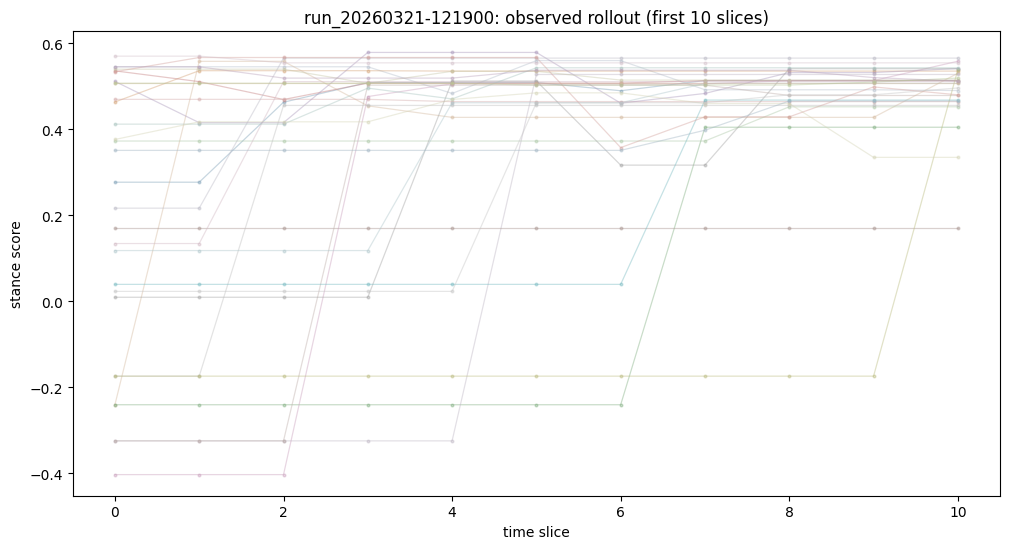

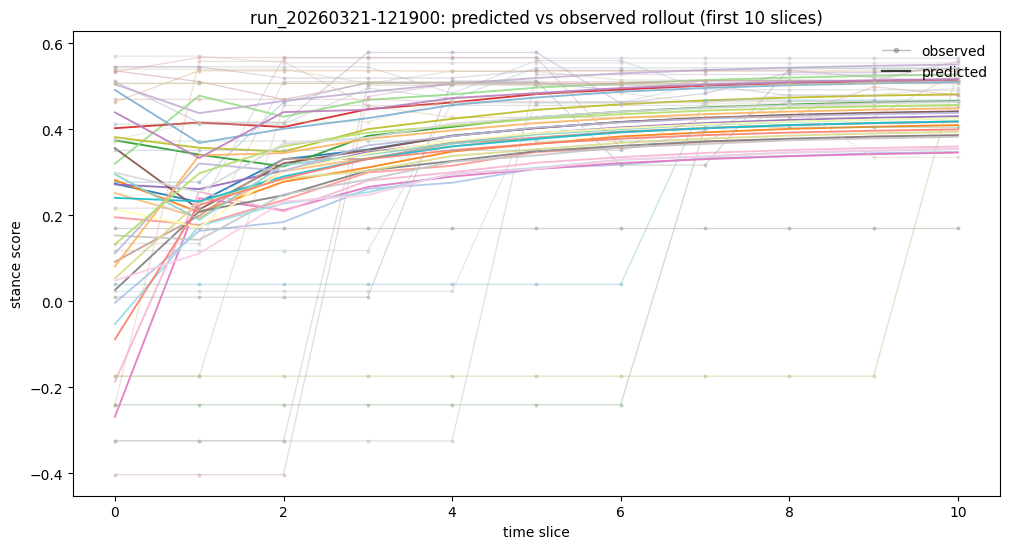

Average steady-state mean (observed): 0.45628570150826153
Average steady-state mean (predicted): 0.4184957506798714
Average steady-state variance (observed): 0.013277781374911962
Average steady-state variance (predicted): 0.0031671025741764696
Average Wasserstein distance: 0.1079


In [18]:
joint_fj = fit_friedkin_johnsen_joint(RUN_TRAJ, RUN_NEIGHBORS, GLOBAL_INIT_BY_AGENT, eps=1e-4)
JOINT_L1 = joint_fj['lambda1']
JOINT_L2 = joint_fj['lambda2']
JOINT_ALPHA = joint_fj['alpha']
JOINT_B = joint_fj['b']
JOINT_W = joint_fj['W']

print('Joint FJ fit (reparameterized)')
print('lambda1:', JOINT_L1)
print('lambda2:', JOINT_L2)
print('alpha = 1-lambda1-lambda2:', JOINT_ALPHA)
print('b:', JOINT_B)
print('Global MSE loss:', joint_fj['mse_pool'])

#print(JOINT_W)


PREDICTED_TRAJ_FJ_JOINT = {
    rn: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        build_x0_from_agent_inits(GLOBAL_INIT_BY_AGENT, N),
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    )
    for rn, tr in RUN_TRAJ.items()
}

run_names = sorted(RUN_TRAJ.keys())

run_id = run_names[10]
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ_JOINT[run_id], GLOBAL_AGENT_IDS, 10)
per_run_metrics_joint = []
per_run_wass_joint = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ_JOINT[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]
    per_run_metrics_joint.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass_joint.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs_joint = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics_joint]))
avg_mean_pred_joint = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics_joint]))
avg_var_obs_joint = float(np.mean([m['steady_var_obs'] for m in per_run_metrics_joint]))
avg_var_pred_joint = float(np.mean([m['steady_var_pred'] for m in per_run_metrics_joint]))
avg_wasserstein_joint = float(np.mean(per_run_wass_joint))

print(f"Average steady-state mean (observed): {avg_mean_obs_joint}")
print(f"Average steady-state mean (predicted): {avg_mean_pred_joint}")
print(f"Average steady-state variance (observed): {avg_var_obs_joint}")
print(f"Average steady-state variance (predicted): {avg_var_pred_joint}")
print(f"Average Wasserstein distance: {avg_wasserstein_joint:.4f}")

In [19]:
def fit_friedkin_johnsen_joint_traj0(run_traj_map,run_neighbors,eps=1e-4):
    run_names=sorted(run_traj_map.keys())
    ref_neighbors=run_neighbors[run_names[0]]

    for rn in run_names[1:]:
        if run_neighbors[rn]!=ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')
        
    X_blocks=[]
    Y_blocks=[]
    X0_blocks=[]
    for rn in run_names:
        traj=np.asarray(run_traj_map[rn],dtype=float)
        X,Y=build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)
        X0_blocks.append(np.repeat(traj[0].reshape(1,-1),X.shape[0],axis=0))

    X_pool=np.vstack(X_blocks)
    Y_pool=np.vstack(Y_blocks)
    X0_pool=np.vstack(X0_blocks)
    _,n=X_pool.shape

    lambda1=cp.Variable(nonneg=True)
    lambda2=cp.Variable(nonneg=True)
    b_tilde=cp.Variable()
    alpha=1.0-lambda1-lambda2
    W_tilde=cp.Variable((n,n))
    ones_n=np.ones((n,),dtype=float)
    residual=Y_pool-(lambda1*X0_pool+b_tilde*ones_n[None,:]+X_pool@W_tilde.T)
    objective=cp.Minimize(cp.sum_squares(residual))
    constraints=[lambda2>=eps, lambda1+lambda2<=1.0-eps,lambda1<=1.0]

    for i in range(n):
        ns=ref_neighbors[i]
        allowed=np.zeros((n,),dtype=float)
        allowed[np.asarray(ns,dtype=int)]=1.0
        constraints.append(W_tilde[i,:]>=0)
        constraints.append(cp.sum(W_tilde[i,:])==alpha)
        constraints.append(cp.multiply(1.0-allowed,W_tilde[i,:])==0)
    constraints+=[b_tilde<=lambda2,b_tilde>=-lambda2]
    prob=cp.Problem(objective,constraints)
    prob.solve(solver=cp.OSQP)

    if lambda1.value is None or lambda2.value is None or W_tilde.value is None or b_tilde.value is None:
        raise RuntimeError('Joint FJ traj0 optimization failed to produce a solution.')
    lambda1_hat=float(lambda1.value)
    lambda2_hat=float(lambda2.value)
    alpha_hat=1.0-lambda1_hat-lambda2_hat
    b_tilde_hat=float(b_tilde.value)
    W_tilde_hat=np.asarray(W_tilde.value,dtype=float)
    if alpha_hat<=eps:
        raise RuntimeError(f'Estimated alpha too small for stable W recovery: alpha={alpha_hat}')
    
    W_hat=W_tilde_hat/alpha_hat
    b_hat=b_tilde_hat/lambda2_hat
    fitted_pool=lambda1_hat*X0_pool+b_tilde_hat*ones_n[None,:]+X_pool@W_tilde_hat.T
    mse_pool=float(np.mean((Y_pool-fitted_pool)**2))
    return {'lambda1':lambda1_hat,'lambda2':lambda2_hat,'alpha':alpha_hat,'b_tilde':b_tilde_hat,'W_tilde':W_tilde_hat,'W':W_hat,'b':float(b_hat),'X_pool':X_pool,'Y_pool':Y_pool,'X0_pool':X0_pool,'mse_pool':mse_pool,'status':prob.status,'objective':float(prob.value) if prob.value is not None else np.nan}

Joint FJ fit (reparameterized)
lambda1: 0.22236867555648743
lambda2: 0.11271499990181011
alpha = 1-lambda1-lambda2: 0.6649163245417025
b: 0.7717051663789439
Global MSE loss: 0.02280358149017578


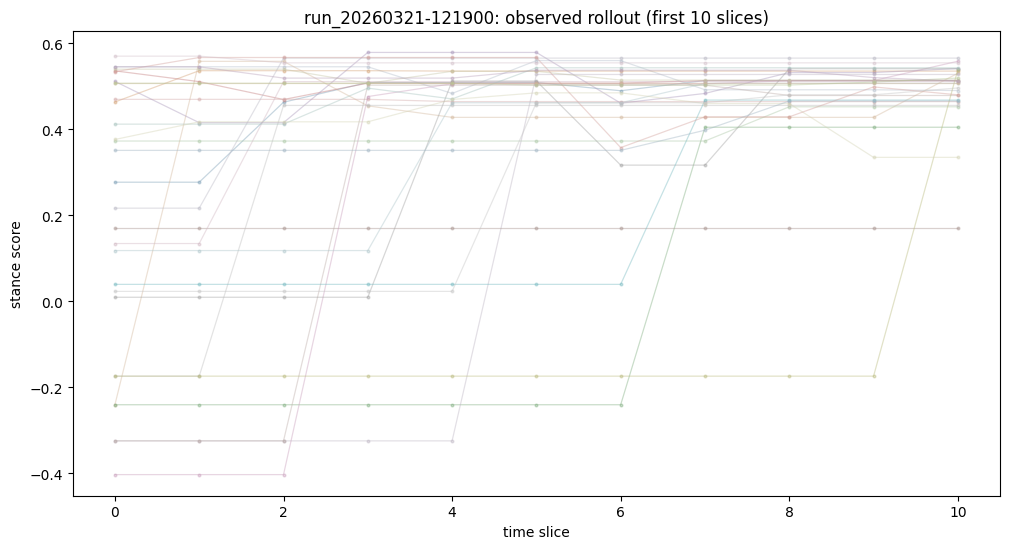

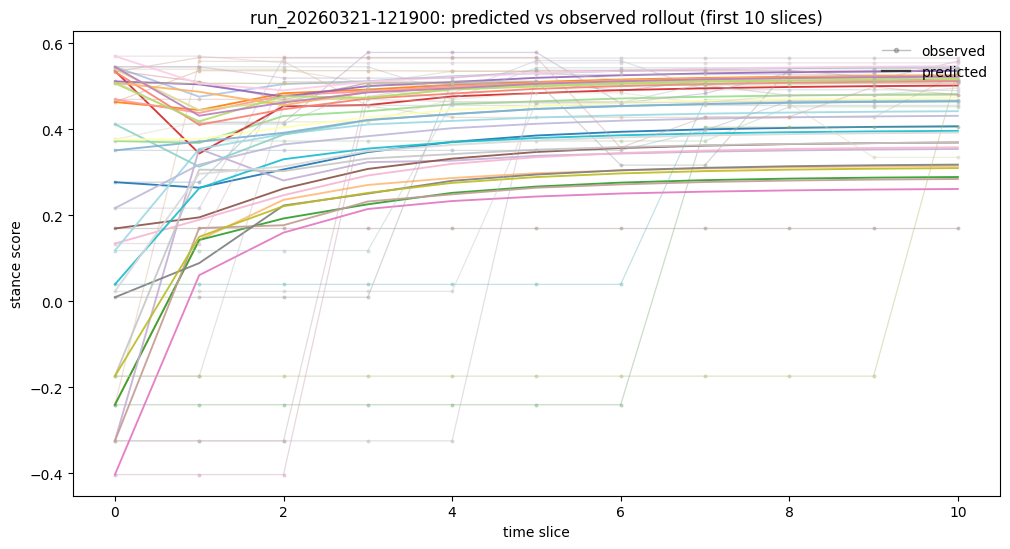

Average steady-state mean (observed): 0.45628570150826153
Average steady-state mean (predicted): 0.44839998892594246
Average steady-state variance (observed): 0.013277781374911962
Average steady-state variance (predicted): 0.005505617798897248
Average Wasserstein distance: 0.0631


In [20]:
joint_fj = fit_friedkin_johnsen_joint_traj0(RUN_TRAJ, RUN_NEIGHBORS, eps=1e-4)
JOINT_L1 = joint_fj['lambda1']
JOINT_L2 = joint_fj['lambda2']
JOINT_ALPHA = joint_fj['alpha']
JOINT_B = joint_fj['b']
JOINT_W = joint_fj['W']

print('Joint FJ fit (reparameterized)')
print('lambda1:', JOINT_L1)
print('lambda2:', JOINT_L2)
print('alpha = 1-lambda1-lambda2:', JOINT_ALPHA)
print('b:', JOINT_B)
print('Global MSE loss:', joint_fj['mse_pool'])

#print(JOINT_W)


PREDICTED_TRAJ_FJ_JOINT = {
    rn: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        np.asarray(RUN_TRAJ[rn],dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    )
    for rn, tr in RUN_TRAJ.items()
}

run_names = sorted(RUN_TRAJ.keys())

run_id = run_names[10]
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ_JOINT[run_id], GLOBAL_AGENT_IDS, 10)
per_run_metrics_joint = []
per_run_wass_joint = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ_JOINT[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]
    per_run_metrics_joint.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass_joint.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs_joint = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics_joint]))
avg_mean_pred_joint = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics_joint]))
avg_var_obs_joint = float(np.mean([m['steady_var_obs'] for m in per_run_metrics_joint]))
avg_var_pred_joint = float(np.mean([m['steady_var_pred'] for m in per_run_metrics_joint]))
avg_wasserstein_joint = float(np.mean(per_run_wass_joint))

print(f"Average steady-state mean (observed): {avg_mean_obs_joint}")
print(f"Average steady-state mean (predicted): {avg_mean_pred_joint}")
print(f"Average steady-state variance (observed): {avg_var_obs_joint}")
print(f"Average steady-state variance (predicted): {avg_var_pred_joint}")
print(f"Average Wasserstein distance: {avg_wasserstein_joint:.4f}")